# MIMIC Data Exploration

Two things to poke at here:

1. **Raw MIMIC-IV source tables** (hosp / note / ED) as configured in `src/.env` (`MIRA_MIMIC_*_DIR`).
2. **The diagnosis dataset built by step 3** (`scripts/02_make_dataset_small.sh` / `03_make_dataset_full.sh`), i.e. what `src/dataset/make_dataset.py` writes to `src/raw/derived/diagnosis_datasets/<diagnosis>/`.

Canonical working directory: `HospitalAgent/src/notebooks/` (this file's own folder) — the bootstrap cell below adds `src/` to `sys.path` so imports like `paths`, `dataset.data`, `dataset.mimic_dataset` resolve the same way they do in `build_procedure_db.ipynb`.

In [1]:
import sys
from pathlib import Path

for candidate in (Path.cwd(), Path.cwd().parent):
    if (candidate / 'dataset').exists() and (candidate / 'paths.py').exists():
        candidate_str = str(candidate.resolve())
        if candidate_str not in sys.path:
            sys.path.insert(0, candidate_str)
        break

In [2]:
import pandas as pd

pd.set_option("display.max_columns", 50)
pd.set_option("display.max_colwidth", 120)

## 1. Raw MIMIC-IV hosp tables

Loaded straight off disk via `dataset.data` (same paths `01_check_mimic_paths.sh` validated: `MIRA_MIMIC_HOSP_DIR`).

In [3]:
from dataset.data import (
    BASE_HOSP,
    admissions_path,
    d_icd_diagnoses_path,
    d_icd_procedures_path,
    d_labitems_path,
    diagnoses_icd_path,
    labevents_path,
    microbiologyevents_path,
    patients_path,
    prescriptions_path,
    procedures_path,
    transfers_path,
)

patients = pd.read_csv(BASE_HOSP / patients_path)
admissions = pd.read_csv(BASE_HOSP / admissions_path)
transfers = pd.read_csv(BASE_HOSP / transfers_path)

print("patients:", patients.shape)
print("admissions:", admissions.shape)
print("transfers:", transfers.shape)
patients.head()

patients: (364627, 6)
admissions: (546028, 16)
transfers: (2413581, 7)


,subject_id,gender,anchor_age,anchor_year,anchor_year_group,dod
0,10000032,F,52,2180,2014 - 2016,2180-09-09
1,10000048,F,23,2126,2008 - 2010,NaN
2,10000058,F,33,2168,2020 - 2022,NaN
3,10000068,F,19,2160,2008 - 2010,NaN
4,10000084,M,72,2160,2017 - 2019,2161-02-13


In [4]:
admissions.head()

,subject_id,hadm_id,admittime,dischtime,deathtime,admission_type,admit_provider_id,admission_location,discharge_location,insurance,language,marital_status,race,edregtime,edouttime,hospital_expire_flag
0,10000032,22595853,2180-05-06 22:23:00,2180-05-07 17:15:00,NaN,URGENT,P49AFC,TRANSFER FROM HOSPITAL,HOME,Medicaid,English,WIDOWED,WHITE,2180-05-06 19:17:00,2180-05-06 23:30:00,0
1,10000032,22841357,2180-06-26 18:27:00,2180-06-27 18:49:00,NaN,EW EMER.,P784FA,EMERGENCY ROOM,HOME,Medicaid,English,WIDOWED,WHITE,2180-06-26 15:54:00,2180-06-26 21:31:00,0
2,10000032,25742920,2180-08-05 23:44:00,2180-08-07 17:50:00,NaN,EW EMER.,P19UTS,EMERGENCY ROOM,HOSPICE,Medicaid,English,WIDOWED,WHITE,2180-08-05 20:58:00,2180-08-06 01:44:00,0
3,10000032,29079034,2180-07-23 12:35:00,2180-07-25 17:55:00,NaN,EW EMER.,P06OTX,EMERGENCY ROOM,HOME,Medicaid,English,WIDOWED,WHITE,2180-07-23 05:54:00,2180-07-23 14:00:00,0
4,10000068,25022803,2160-03-03 23:16:00,2160-03-04 06:26:00,NaN,EU OBSERVATION,P39NWO,EMERGENCY ROOM,NaN,NaN,English,SINGLE,WHITE,2160-03-03 21:55:00,2160-03-04 06:26:00,0


In [5]:
# Diagnoses: diagnoses_icd + long titles from d_icd_diagnoses
d_icd_diagnoses = pd.read_csv(BASE_HOSP / d_icd_diagnoses_path)
diagnoses_icd = pd.read_csv(BASE_HOSP / diagnoses_icd_path)

diagnoses_icd_annot = diagnoses_icd.merge(
    d_icd_diagnoses[["icd_code", "icd_version", "long_title"]],
    on=["icd_code", "icd_version"],
    how="left",
)
print(diagnoses_icd_annot.shape)
diagnoses_icd_annot.head()

(6364488, 6)


,subject_id,hadm_id,seq_num,icd_code,icd_version,long_title
0,10000032,22595853,1,5723,9,Portal hypertension
1,10000032,22595853,2,78959,9,Other ascites
2,10000032,22595853,3,5715,9,Cirrhosis of liver without mention of alcohol
3,10000032,22595853,4,07070,9,Unspecified viral hepatitis C without hepatic coma
4,10000032,22595853,5,496,9,"Chronic airway obstruction, not elsewhere classified"


In [6]:
# Most common diagnoses in the raw hosp table (sanity check / picking a diagnosis to build a dataset for)
diagnoses_icd_annot["long_title"].value_counts().head(20)

long_title
Unspecified essential hypertension                                                                            102368
Hyperlipidemia, unspecified                                                                                    84570
Essential (primary) hypertension                                                                               83775
Other and unspecified hyperlipidemia                                                                           67293
Acute kidney failure, unspecified                                                                              65020
Personal history of nicotine dependence                                                                        62806
Gastro-esophageal reflux disease without esophagitis                                                           56157
Esophageal reflux                                                                                              48628
Anemia, unspecified                                  

In [7]:
# Procedures: procedures_icd + long titles from d_icd_procedures
d_icd_procedures = pd.read_csv(BASE_HOSP / d_icd_procedures_path)
procedures_icd = pd.read_csv(BASE_HOSP / procedures_path)

procedures_icd_annot = procedures_icd.merge(
    d_icd_procedures[["icd_code", "icd_version", "long_title"]],
    on=["icd_code", "icd_version"],
    how="left",
)
print(procedures_icd_annot.shape)
procedures_icd_annot.head()

(859655, 7)


,subject_id,hadm_id,seq_num,chartdate,icd_code,icd_version,long_title
0,10000032,22595853,1,2180-05-07,5491,9,Percutaneous abdominal drainage
1,10000032,22841357,1,2180-06-27,5491,9,Percutaneous abdominal drainage
2,10000032,25742920,1,2180-08-06,5491,9,Percutaneous abdominal drainage
3,10000068,25022803,1,2160-03-03,8938,9,Other nonoperative respiratory measurements
4,10000117,27988844,1,2183-09-19,0QS734Z,10,"Reposition Left Upper Femur with Internal Fixation Device, Percutaneous Approach"


In [8]:
# Labs: labevents + d_labitems (note: labevents.csv is large, this can take a bit)
d_labitems = pd.read_csv(BASE_HOSP / d_labitems_path)
lab_events = pd.read_csv(BASE_HOSP / labevents_path, nrows=200_000)  # sampled — drop nrows for the full table

lab_events_annot = lab_events.merge(d_labitems, on="itemid", how="left")
print(lab_events_annot.shape)
lab_events_annot[["subject_id", "hadm_id", "charttime", "label", "fluid", "valuenum", "valueuom"]].head()

(200000, 19)


,subject_id,hadm_id,charttime,label,fluid,valuenum,valueuom
0,10000032,NaN,2180-03-23 11:51:00,Glucose,Blood,95.0,mg/dL
1,10000032,NaN,2180-03-23 11:51:00,"Amphetamine Screen, Urine",Urine,NaN,NaN
2,10000032,NaN,2180-03-23 11:51:00,"Barbiturate Screen, Urine",Urine,NaN,NaN
3,10000032,NaN,2180-03-23 11:51:00,"Benzodiazepine Screen, Urine",Urine,NaN,NaN
4,10000032,NaN,2180-03-23 11:51:00,"Cocaine, Urine",Urine,NaN,NaN


In [9]:
prescriptions = pd.read_csv(BASE_HOSP / prescriptions_path, nrows=200_000)  # sampled — drop nrows for the full table
prescriptions.head()

/tmp/ipykernel_2326212/2180958462.py:1: DtypeWarning: Columns (11) have mixed types. Specify dtype option on import or set low_memory=False.
  prescriptions = pd.read_csv(BASE_HOSP / prescriptions_path, nrows=200_000)  # sampled — drop nrows for the full table


,subject_id,hadm_id,pharmacy_id,poe_id,poe_seq,order_provider_id,starttime,stoptime,drug_type,drug,formulary_drug_cd,gsn,ndc,prod_strength,form_rx,dose_val_rx,dose_unit_rx,form_val_disp,form_unit_disp,doses_per_24_hrs,route
0,10000032,22595853,12775705,10000032-55,55.0,P85UQ1,2180-05-08 08:00:00,2180-05-07 22:00:00,MAIN,Furosemide,FURO40,008209,5.107901e+10,40mg Tablet,NaN,40,mg,1,TAB,1.0,PO/NG
1,10000032,22595853,18415984,10000032-42,42.0,P23SJA,2180-05-07 02:00:00,2180-05-07 22:00:00,MAIN,Ipratropium Bromide Neb,IPRA2H,021700,4.879801e+08,2.5mL Vial,NaN,1,NEB,1,VIAL,4.0,IH
2,10000032,22595853,23637373,10000032-35,35.0,P23SJA,2180-05-07 01:00:00,2180-05-07 09:00:00,MAIN,Furosemide,FURO20,008208,5.107901e+10,20mg Tablet,NaN,20,mg,1,TAB,1.0,PO/NG
3,10000032,22595853,26862314,10000032-41,41.0,P23SJA,2180-05-07 01:00:00,2180-05-07 01:00:00,MAIN,Potassium Chloride,MICROK10,001275,2.450041e+08,10mEq ER Tablet,NaN,40,mEq,4,TAB,1.0,PO
4,10000032,22595853,30740602,10000032-27,27.0,P23SJA,2180-05-07 00:00:00,2180-05-07 22:00:00,MAIN,Sodium Chloride 0.9% Flush,NACLFLUSH,NaN,0.000000e+00,10 mL Syringe,NaN,3,mL,0.3,SYR,3.0,IV


In [10]:
microbiologyevents = pd.read_csv(BASE_HOSP / microbiologyevents_path)
print(microbiologyevents.shape)
microbiologyevents.head()

/tmp/ipykernel_2326212/1107758940.py:1: DtypeWarning: Columns (17) have mixed types. Specify dtype option on import or set low_memory=False.
  microbiologyevents = pd.read_csv(BASE_HOSP / microbiologyevents_path)


(3988224, 25)


,microevent_id,subject_id,hadm_id,micro_specimen_id,order_provider_id,chartdate,charttime,spec_itemid,spec_type_desc,test_seq,storedate,storetime,test_itemid,test_name,org_itemid,org_name,isolate_num,quantity,ab_itemid,ab_name,dilution_text,dilution_comparison,dilution_value,interpretation,comments
0,1,10000032,NaN,1304715,P69FQC,2180-03-23 00:00:00,2180-03-23 11:51:00,70046,IMMUNOLOGY,1,2180-03-26 00:00:00,2180-03-26 10:54:00,90123,HCV VIRAL LOAD,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,___
1,2,10000032,NaN,3342526,P69FQC,2180-03-23 00:00:00,2180-03-23 11:51:00,70093,Blood (Toxo),1,2180-03-26 00:00:00,2180-03-26 10:17:00,90144,TOXOPLASMA IgG ANTIBODY,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"NEGATIVE FOR TOXOPLASMA IgG ANTIBODY BY EIA. 0.0 IU/ML. Reference Range: Negative < 4 IU/ml, Positive >= 8 IU/ml...."
2,3,10000032,NaN,3910370,P69FQC,2180-03-23 00:00:00,2180-03-23 11:51:00,70017,SEROLOGY/BLOOD,1,2180-03-24 00:00:00,2180-03-24 05:27:00,90248,RAPID PLASMA REAGIN TEST,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NONREACTIVE. Reference Range: Non-Reactive.
3,4,10000032,NaN,5401234,P69FQC,2180-03-23 00:00:00,2180-03-23 11:51:00,70017,SEROLOGY/BLOOD,1,2180-03-26 00:00:00,2180-03-26 13:38:00,90091,VARICELLA-ZOSTER IgG SEROLOGY,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,POSITIVE BY EIA. A positive IgG result generally indicates past exposure and/or immunity.
4,5,10000032,NaN,6287540,P69FQC,2180-03-23 00:00:00,2180-03-23 11:51:00,70046,IMMUNOLOGY,1,2180-03-26 00:00:00,2180-03-26 10:25:00,90175,HIV-1 Viral Load/Ultrasensitive,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"HIV-1 RNA is not detected. Performed using the ___ HIV-1 Test v2.0. Detection Range: 20-10,000,000 copies/mL. Thi..."


## 2. Raw MIMIC-IV-Note tables

Free-text clinical notes (`MIRA_MIMIC_NOTE_DIR`). `discharge.csv` and `radiology.csv` are large — sample with `nrows` while exploring.

In [11]:
from dataset.data import (
    BASE_NOTE,
    discharge_path,
    radiology_path,
    radiologydetail_path,
)

discharge = pd.read_csv(BASE_NOTE / discharge_path, nrows=5_000)
radiology = pd.read_csv(BASE_NOTE / radiology_path, nrows=5_000)
radiology_detail = pd.read_csv(BASE_NOTE / radiologydetail_path, nrows=5_000)

print("discharge:", discharge.shape)
print("radiology:", radiology.shape)
print("radiology_detail:", radiology_detail.shape)
discharge[["note_id", "subject_id", "hadm_id", "charttime", "text"]].head()

discharge: (5000, 8)
radiology: (5000, 8)
radiology_detail: (5000, 5)


,note_id,subject_id,hadm_id,charttime,text
0,10000032-DS-21,10000032,22595853,2180-05-07 00:00:00,\nName: ___ Unit No: ___\n \nAdmission Date: ___ Discharge Date: ___\n \nDat...
1,10000032-DS-22,10000032,22841357,2180-06-27 00:00:00,\nName: ___ Unit No: ___\n \nAdmission Date: ___ Discharge Date: ___\n \nDat...
2,10000032-DS-23,10000032,29079034,2180-07-25 00:00:00,\nName: ___ Unit No: ___\n \nAdmission Date: ___ Discharge Date: ___\n \nDat...
3,10000032-DS-24,10000032,25742920,2180-08-07 00:00:00,\nName: ___ Unit No: ___\n \nAdmission Date: ___ Discharge Date: ___\n \nDat...
4,10000084-DS-17,10000084,23052089,2160-11-25 00:00:00,\nName: ___ Unit No: ___\n \nAdmission Date: ___ Discharge Date: ___\n \nDate...


In [12]:
# Look at one full discharge note
print(discharge["text"].iloc[0])

 
Name:  ___                     Unit No:   ___
 
Admission Date:  ___              Discharge Date:   ___
 
Date of Birth:  ___             Sex:   F
 
Service: MEDICINE
 
Allergies: 
No Known Allergies / Adverse Drug Reactions
 
Attending: ___
 
Chief Complaint:
Worsening ABD distension and pain 
 
Major Surgical or Invasive Procedure:
Paracentesis

 
History of Present Illness:
___ HCV cirrhosis c/b ascites, hiv on ART, h/o IVDU, COPD, 
bioplar, PTSD, presented from OSH ED with worsening abd 
distension over past week.  
Pt reports self-discontinuing lasix and spirnolactone ___ weeks 
ago, because she feels like "they don't do anything" and that 
she "doesn't want to put more chemicals in her." She does not 
follow Na-restricted diets. In the past week, she notes that she 
has been having worsening abd distension and discomfort. She 
denies ___ edema, or SOB, or orthopnea. She denies f/c/n/v, d/c, 
dysuria. She had food poisoning a week ago from eating stale 
cake (n/v 20 min after fo

In [13]:
radiology[["note_id", "subject_id", "hadm_id", "charttime", "text"]].head()

,note_id,subject_id,hadm_id,charttime,text
0,10000032-RR-14,10000032,22595853.0,2180-05-06 21:19:00,EXAMINATION: CHEST (PA AND LAT)\n\nINDICATION: ___ with new onset ascites // eval for infection\n\nTECHNIQUE: Ch...
1,10000032-RR-15,10000032,22595853.0,2180-05-06 23:00:00,"EXAMINATION: LIVER OR GALLBLADDER US (SINGLE ORGAN)\n\nINDICATION: ___ year-old female with cirrhosis, jaundice.\n..."
2,10000032-RR-16,10000032,22595853.0,2180-05-07 09:55:00,"INDICATION: ___ HCV cirrhosis c/b ascites, hiv on ART, h/o IVDU, COPD,\nbioplar, PTSD, presented from OSH ED with w..."
3,10000032-RR-18,10000032,NaN,2180-06-03 12:46:00,"EXAMINATION: Ultrasound-guided paracentesis.\n\nINDICATION: ___ year old woman with cirrhosis, ascites despite diu..."
4,10000032-RR-20,10000032,NaN,2180-07-08 13:18:00,"EXAMINATION: Paracentesis\n\nINDICATION: ___ year old woman with cirrhosis, ascites despite diuretics //\nPlease ..."


## 3. Raw MIMIC-IV-ED tables

Emergency-department data (`MIRA_MIMIC_ED_DIR`).

In [14]:
from dataset.data import (
    BASE_ED,
    diagnosis_ed_path,
    ed_stays_path,
    medrecon_path,
    pyxis_path,
    triage_path,
    vitalsign_path,
)

diagnosis_ed = pd.read_csv(BASE_ED / diagnosis_ed_path)
ed_stays = pd.read_csv(BASE_ED / ed_stays_path)
medrecon = pd.read_csv(BASE_ED / medrecon_path)
pyxis = pd.read_csv(BASE_ED / pyxis_path)
triage = pd.read_csv(BASE_ED / triage_path)
vitalsign = pd.read_csv(BASE_ED / vitalsign_path, nrows=200_000)  # sampled — drop nrows for the full table

for name, df in [
    ("diagnosis_ed", diagnosis_ed),
    ("ed_stays", ed_stays),
    ("medrecon", medrecon),
    ("pyxis", pyxis),
    ("triage", triage),
    ("vitalsign", vitalsign),
]:
    print(f"{name}: {df.shape}")

diagnosis_ed: (899050, 6)
ed_stays: (425087, 9)
medrecon: (2987342, 9)
pyxis: (1586053, 7)
triage: (425087, 11)
vitalsign: (200000, 11)


In [15]:
ed_stays.head()

,subject_id,hadm_id,stay_id,intime,outtime,gender,race,arrival_transport,disposition
0,10000032,22595853.0,33258284,2180-05-06 19:17:00,2180-05-06 23:30:00,F,WHITE,AMBULANCE,ADMITTED
1,10000032,22841357.0,38112554,2180-06-26 15:54:00,2180-06-26 21:31:00,F,WHITE,AMBULANCE,ADMITTED
2,10000032,25742920.0,35968195,2180-08-05 20:58:00,2180-08-06 01:44:00,F,WHITE,AMBULANCE,ADMITTED
3,10000032,29079034.0,32952584,2180-07-22 16:24:00,2180-07-23 05:54:00,F,WHITE,AMBULANCE,HOME
4,10000032,29079034.0,39399961,2180-07-23 05:54:00,2180-07-23 14:00:00,F,WHITE,AMBULANCE,ADMITTED


In [16]:
triage.head()

,subject_id,stay_id,temperature,heartrate,resprate,o2sat,sbp,dbp,pain,acuity,chiefcomplaint
0,10000032,32952584,97.8,87.0,14.0,97.0,71.0,43.0,7,2.0,Hypotension
1,10000032,33258284,98.4,70.0,16.0,97.0,106.0,63.0,0,3.0,"Abd pain, Abdominal distention"
2,10000032,35968195,99.4,105.0,18.0,96.0,106.0,57.0,10,3.0,"n/v/d, Abd pain"
3,10000032,38112554,98.9,88.0,18.0,97.0,116.0,88.0,10,3.0,Abdominal distention
4,10000032,39399961,98.7,77.0,16.0,98.0,96.0,50.0,13,2.0,"Abdominal distention, Abd pain, LETHAGIC"


## 4. The built diagnosis dataset (post step 3)

This is what `scripts/02_make_dataset_small.sh` (or `03_make_dataset_full.sh`) produced: a filtered, joined, per-diagnosis dataset saved under `DIAGNOSIS_DATASETS_DIR` (default `src/raw/derived/diagnosis_datasets`, or `MIRA_DIAGNOSIS_DATASETS_DIR` if set). This is what the simulation step (step 7 / `run_simulation.ipynb`) actually reads at runtime — not the raw CSVs directly.

In [17]:
from paths import DIAGNOSIS_DATASETS_DIR

print("Looking in:", DIAGNOSIS_DATASETS_DIR)
available_datasets = sorted(p.name for p in DIAGNOSIS_DATASETS_DIR.glob("*") if p.is_dir())
available_datasets

Looking in: /home/mwei26/codebase/MIRA/src/raw/derived/diagnosis_datasets


['appendicitis']

In [18]:
from dataset.mimic_dataset import MIMIC_Dataset

# pick one of the names printed above (e.g. "appendicitis")
DATASET_NAME = available_datasets[0]

ds = MIMIC_Dataset.load_dataset(DATASET_NAME)
print("diagnosis:", ds.diagnosis)
print("num admissions (hadm_ids):", len(ds))
print("tables:", ds.list_tables())

15it [00:00, 188.43it/s]

diagnosis: appendicitis
num admissions (hadm_ids): 3
tables: ['lab_events', 'history_pe_admedication_diagnosis', 'microbiology', 'radiology', 'medication', 'procedures_icd', 'diagnosis_icd', 'diagnosis_ed', 'ed_stays', 'medrecon', 'pyxis', 'triage', 'vitalsign', 'admissions', 'patients']


In [19]:
# Row counts per table for the whole dataset
for table_name in ds.list_tables():
    df = getattr(ds, table_name)
    print(f"{table_name:35s} {df.shape}")

lab_events                          (99, 38)
history_pe_admedication_diagnosis   (3, 8)
microbiology                        (7, 27)
radiology                           (3, 15)
medication                          (37, 22)
procedures_icd                      (18, 7)
diagnosis_icd                       (11, 7)
diagnosis_ed                        (3, 9)
ed_stays                            (3, 9)
medrecon                            (12, 10)
pyxis                               (15, 8)
triage                              (3, 12)
vitalsign                           (7, 12)
admissions                          (3, 16)
patients                            (3, 7)


In [20]:
# Pull a single admission out of the dataset (this is exactly what `ds[hadm_id]` / `next(iter(ds))`
# returns inside prepare_patient() in src/runs/run.py, i.e. the `patient_data` object the tools use)
hadm_id = next(iter(ds.hadm_ids))
admission = ds[hadm_id]

print("hadm_id:", hadm_id)
admission.patients

hadm_id: 20345216


,subject_id,gender,anchor_age,anchor_year,anchor_year_group,dod,hadm_id
2892,10080679,M,28,2155,2011 - 2013,None,20345216.0


In [21]:
admission.admissions

,subject_id,hadm_id,admittime,dischtime,deathtime,admission_type,admit_provider_id,admission_location,discharge_location,insurance,language,marital_status,race,edregtime,edouttime,hospital_expire_flag
4117,10080679,20345216,2155-02-28 05:10:00,2155-03-01 11:55:00,None,EW EMER.,P43ACO,EMERGENCY ROOM,HOME,Private,English,SINGLE,ASIAN - CHINESE,2155-02-28 02:04:00,2155-02-28 05:36:00,0


In [22]:
admission.diagnosis_icd

,subject_id,hadm_id,seq_num,icd_code,icd_version,long_title,is_invalid
48496,10080679,20345216,1,5409,9,Acute appendicitis without mention of peritonitis,False


In [23]:
# The LLM-extracted structured summary of the discharge note for this admission
# (history / physical exam / admission medication / diagnosis) — this is what
# get_physical_exam_results() etc. read from at simulation time.
row = admission.history_pe_admedication_diagnosis
for col in row.columns:
    print(f"--- {col} ---")
    print(row[col].values[0])
    print()

--- hadm_id ---
20345216

--- text ---
 
Name:  ___                       Unit No:   ___
 
Admission Date:  ___              Discharge Date:   ___
 
Date of Birth:  ___             Sex:   M
 
Service: SURGERY
 
Allergies: 
No Known Allergies / Adverse Drug Reactions
 
Attending: ___.
 
Chief Complaint:
Abdominal pain.
 
Major Surgical or Invasive Procedure:
___ Laparoscopic appendectomy

 
History of Present Illness:
Mr. ___ is an otherwise healthy ___ man who presents with
10h history of abdominal pain. The pain began periumbilically 
and
migrated to the right lower quadrant. He initially had one
episode of diarrhea. Has not had any nausea or emesis. Denies
fevers or chills. He has not wanted to eat since the pain began.

 
Past Medical History:
Past Medical History: seasonal and food allergies

Past Surgical History: pilonidal cyst excision

 
Social History:
___
Family History:
Non-contributory
 
Physical Exam:
On admission:

Vitals: 98.1 95 124/61 22 96%  
GEN: A&O, NAD
HEENT: No s

In [ ]:
admission.lab_events.head()

In [ ]:
admission.radiology[["hadm_id", "charttime", "text"]] if "text" in admission.radiology.columns else admission.radiology.head()

## 5. Other exploration

A few quick sanity/coverage checks across the built dataset.

In [24]:
# Admission count and average length-of-stay-ish signal per built dataset (if you've built more than one diagnosis)
for name in available_datasets:
    d = MIMIC_Dataset.load_dataset(name)
    print(f"{name:25s} admissions={len(d):4d}")

15it [00:00, 363.20it/s]

appendicitis              admissions=   3


In [25]:
# Missingness of the extracted per-admission summary fields (history/pe/admission-meds/diagnosis)
hpad = ds.history_pe_admedication_diagnosis
hpad.isna().mean().sort_values(ascending=False)

hadm_id                             0.0
text                                0.0
extracted_history                   0.0
pe                                  0.0
admission_medication                0.0
discharge_diagnosis_from_text       0.0
procedures_from_discharge_letter    0.0
is_invalid                          0.0
dtype: float64

count       3.000000
mean      832.000000
std       356.080047
min       493.000000
25%       646.500000
50%       800.000000
75%      1001.500000
max      1203.000000
Name: extracted_history, dtype: float64


<Axes: >

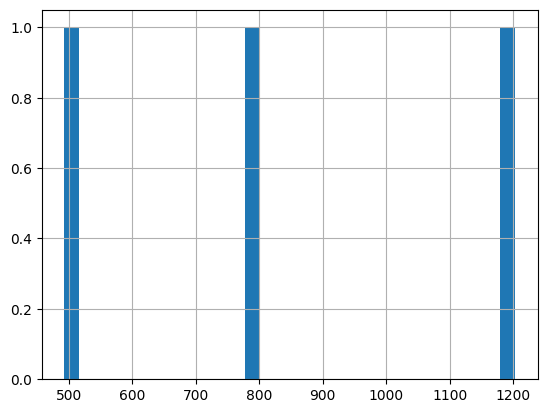

In [26]:
# Distribution of discharge-note-derived free text length (proxy for how much context the agent gets)
import numpy as np

lengths = hpad["extracted_history"].dropna().astype(str).str.len()
print(lengths.describe())
lengths.hist(bins=30)

In [27]:
# Coverage: how many admissions have at least one lab / radiology / microbiology entry
for table_name in ["lab_events", "radiology", "microbiology", "medication"]:
    df = getattr(ds, table_name)
    covered = df["hadm_id"].nunique()
    print(f"{table_name:15s} {covered}/{len(ds)} admissions have >=1 row")

lab_events      3/3 admissions have >=1 row
radiology       3/3 admissions have >=1 row
microbiology    3/3 admissions have >=1 row
medication      3/3 admissions have >=1 row
